<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

# 03: Linear regression 

----
*Georg Kaufmann,
Geophysics Section,
Institute of Geological Sciences,
Freie Universität Berlin,
Germany*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Create sample data set

We first create a sample data set, using a polynomial function $f(x)$, and shaking both the
$x$ and the $y$ coordinates with uniform random noise:

In [2]:
def f(x):
    y = x**3
    return y

In [3]:
n = 21
np.random.seed(1234)
x = np.sort(np.random.uniform(-2,2,n))
#x = np.linspace(-2,2,n)
np.random.seed(1234)
y = f(x) + np.random.uniform(-2,2,n)

print(x.shape,y.shape)

(21,) (21,)


We plot the function. The cubic polynom can still be seen, but the random noise distorts it quite a bit.

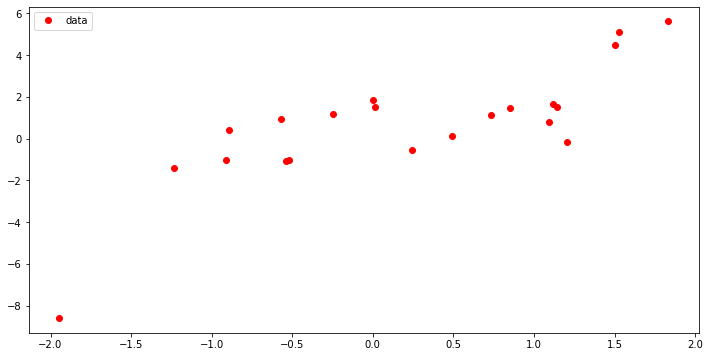

In [4]:
# plot data points
fig=plt.figure(figsize=(12.0, 6.0))
plt.plot(x,y,marker='o',linestyle='none',color='red',label='data')
plt.legend()
plt.show()

Next, we want to use the data set in a **machine learning** algorithm. As we have seen  before,
the **feature matrix** $X$ has to be a two-dimensional array, even in the case with just
**one** feature, the $x$ coordinate.

We therefor need to extend the data array into the 2nd dimension for machine-learning algorithms:

In [5]:
#X = x[:, np.newaxis]
X=x.reshape(n,1)
print(X.shape)

(21, 1)


## Ordinary Least Squares

We want to minimize a residual $\chi^2$, with $y_i$ our **target vector** (the $y$ values) and
$X_{ij}$ our **feature matrix** (the $x$ values), with only one feature ($j=1$):
$$
\chi^2 = \sum\limits_{i=1}^{n} |y_i - X_{ij} w_j|^2
$$
We are looking for the **weights** $w_i=(w_0,w_1,\dots,w_n)$, which satisfy the prediction
$$
p_i(w_j) = w_0 + w_1 x_1 + \dots w_n x_n
$$

In our case
$$
\chi^2 = \sum\limits_{i=1}^{n} |y_i - w_0 - w_1 x_i|^2
$$
with
- $w_0$: intercept,
- $w_1$: slope.

Load the `LinearRegression` module from `scikit_learn`, assign as instance, then call the **fitting part**:
`reg.fit`.

In [12]:
from sklearn import linear_model
from sklearn.metrics import r2_score
reg = linear_model.LinearRegression()
reg.fit(X,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

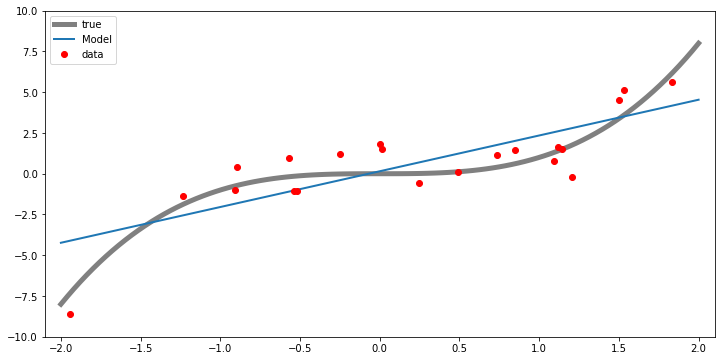

Score:      0.8286148992639063
Intercept:  0.1517360721352664
Slope:      [2.19301877]


In [13]:
x_pred = np.linspace(-2,2,100)
y_pred = reg.predict(x_pred[:, np.newaxis])
fig=plt.figure(figsize=(12.0, 6.0))
plt.xlim([-2.1,2.1])
plt.ylim([-10,10])
plt.plot(x_pred, f(x_pred),linewidth=5,color='gray',label="true")
plt.plot(x_pred, y_pred,linewidth=2,label="Model")
plt.plot(x,y,marker='o',linestyle='none',color='red',label='data')
plt.legend()
plt.show()
print ('Score:     ',reg.score(x_pred[:, np.newaxis],f(x_pred)))
print ('Intercept: ',reg.intercept_)
print ('Slope:     ',reg.coef_)

## Ridge regression

An extension of the **ordinary least square regression** is the **ridge regression**. Here,
minimisation is done over the sum of two terms:
1. least-squares term: $\sum_n |y_i - X_{ij} w_j|^2$
2. regularisation term: $\alpha |w_i|^2$

The resulting residual $\chi^2$, with $y_i$ our **target vector** (the $y$ values) and
$X_{ij}$ our **feature matrix** (the $x$ values), with only one feature ($j=1$), is:
$$
\chi^2 = \sum\limits_{i=1}^{n} |y_i - X_{ij} w_j|^2 + \alpha |w_i|^2
$$
Here, $\alpha$ is a weight for the regularistion term, with $\alpha=0$ reproducing the
least-squares solution.

The regularisation term $|w_i|^2$ will force the feature vector $w_i$ to have a **small length**,
thus the individual coefficients of the feature vector $w_i$ are of similar magnitude.

In [14]:
from sklearn import linear_model 
ridge = linear_model.Ridge(alpha=0.5)
ridge.fit(X,y)

Ridge(alpha=0.5, copy_X=True, fit_intercept=True, max_iter=None,
      normalize=False, random_state=None, solver='auto', tol=0.001)

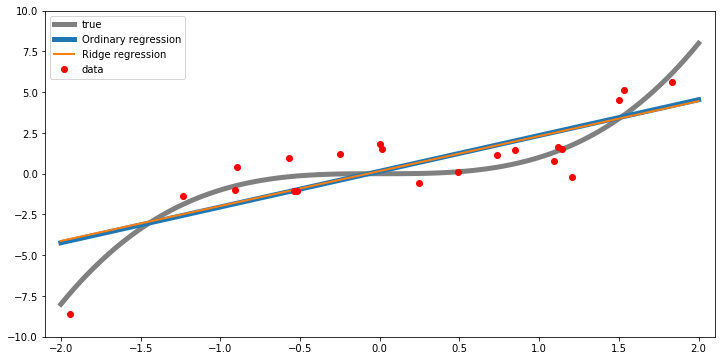

Score:      0.8243164711158886


In [18]:
x_pred = np.linspace(-2,2,100)
y_pred = reg.predict(x_pred[:, np.newaxis])
fig=plt.figure(figsize=(12.0, 6.0))
plt.xlim([-2.1,2.1])
plt.ylim([-10,10])
plt.plot(x_pred, f(x_pred),linewidth=5,color='gray',label="true")
plt.plot(x_pred, y_pred,linewidth=5,label="Ordinary regression")
plt.plot(x_pred, ridge.predict(x_pred[:, np.newaxis]),linewidth=2,label="Ridge regression")
plt.plot(x,y,marker='o',linestyle='none',color='red',label='data')
plt.legend()
plt.show()
print ('Score:     ',ridge.score(x_pred[:, np.newaxis],f(x_pred)))

## Excursion: Scaling features

If the feature matrix includes features with largely varying ranges, is it better to **normalize**
the feature matrix before attempting a fit. This can be done with the `StandardScaler` method from
**preprocessor** library.

The `StandardScaler` calcumates mean $\mu$ and standard deviation $\sigma$ for each column in
the feature matrix $X$, which are then used to transform the feature matrix $\bar{X}$:
$$
\bar{X} = {{X-\mu}\over{\sigma}}
$$
This is done with two steps, first calculating mean and standard deviation with the `fit` method,
then changing the feature matrix with the `transform` method.

As an example, consider a feature matrix $X=[0,1,2,3,4,5,6,7,8,9,10]$.

Note that the `StandardScaler` calculates the variance, $\sigma^2$, but uses standard deviation $\sigma$
to scale...

In [ ]:
from sklearn.preprocessing import StandardScaler
# define feature matrix
a=np.array([0,1,2,3,4,5,6,7,8,9,10])
print('mean:     ',a.mean())
print('variance: ',a.var())
print('std dev:  ',a.std())
# create feature matrix
A=a.reshape(len(a),1)
print(A)
# calculate mean and variance
scaler=StandardScaler()
scaler.fit(A)
print('Scaling parameter: ',scaler.mean_,scaler.var_)
# apply transform to feature matrix
A=scaler.transform(A)
print(A)

## Stochastic gradient descend

text

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import  SGDRegressor
#scaler = StandardScaler()
#scaler.fit(X)
#X = scaler.transform(X)

sgd = SGDRegressor()
sgd.fit(X,y)

SGDRegressor(alpha=0.0001, average=False, early_stopping=False, epsilon=0.1,
             eta0=0.01, fit_intercept=True, l1_ratio=0.15,
             learning_rate='invscaling', loss='squared_loss', max_iter=1000,
             n_iter_no_change=5, penalty='l2', power_t=0.25, random_state=None,
             shuffle=True, tol=0.001, validation_fraction=0.1, verbose=0,
             warm_start=False)

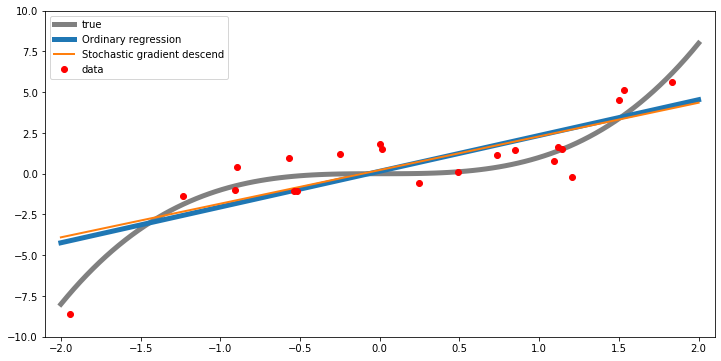

Score:      0.8243164711158886


In [23]:
x_pred = np.linspace(-2,2,100)
y_pred_reg = reg.predict(x_pred[:, np.newaxis])
y_pred_sgd = sgd.predict(x_pred[:, np.newaxis])
fig=plt.figure(figsize=(12.0, 6.0))
plt.xlim([-2.1,2.1])
plt.ylim([-10,10])
plt.plot(x_pred, f(x_pred),linewidth=5,color='gray',label="true")
plt.plot(x_pred, y_pred_reg,linewidth=5,label="Ordinary regression")
plt.plot(x_pred, y_pred_sgd,linewidth=2,label="Stochastic gradient descend")
plt.plot(x,y,marker='o',linestyle='none',color='red',label='data')
plt.legend()
plt.show()
print ('Score:     ',ridge.score(x_pred[:, np.newaxis],f(x_pred)))

[next>](04_regression2.ipynb)